In [ ]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path so `from tools...` imports work from any notebook subfolder.
_p = Path.cwd().resolve()
for _parent in [_p, *_p.parents]:
    if (_parent / 'tools' / 'search_tools.py').exists():
        sys.path.insert(0, str(_parent))
        break
del _p, _parent


In [1]:
%%capture --no-stderr
# %pip install "autogen-agentchat~=0.2.3"

# In Your OAI_CONFIG_LIST file, you must have two configs,
# one with:           "response_format": { "type": "text" }
# and the other with: "response_format": { "type": "json_object" }


[
    {"model": "gpt-4o-mini", "sk-REDACTED": "key go here", "response_format": {"type": "text"}},
]

In [2]:
import autogen
import os
from autogen.agentchat import UserProxyAgent
from autogen.agentchat.assistant_agent import AssistantAgent
from autogen.agentchat.groupchat import GroupChat
os.environ["SERPER_API_KEY"] = "1edefaec0732d11db50b993ba60539510cc55334"
from tools.search_tools import SearchTools




In [3]:
from autogen import ConversableAgent
from autogen import register_function

import os
import json
import requests

def search_internet(query: str) -> str:
        """Useful to search the internet
        about a a given topic and return relevant results"""
        print("Searching the internet...")
        top_result_to_return = 5
        url = "https://google.serper.dev/search"
        payload = json.dumps(
            {"q": query, "num": top_result_to_return, "tbm": "nws"})
        headers = {
            'X-API-KEY': os.environ['SERPER_API_KEY'],
            'content-type': 'application/json'
        }
        response = requests.request("POST", url, headers=headers, data=payload)
        # check if there is an organic key
        if 'organic' not in response.json():
            return "Sorry, I couldn't find anything about that, there could be an error with you serper api key."
        else:
            results = response.json()['organic']
            string = []
            print("Results:", results[:top_result_to_return])
            for result in results[:top_result_to_return]:
                try:
                    # Attempt to extract the date
                    date = result.get('date', 'Date not available')
                    string.append('\n'.join([
                        f"Title: {result['title']}",
                        f"Link: {result['link']}",
                        f"Date: {date}",  # Include the date in the output
                        f"Snippet: {result['snippet']}",
                        "\n-----------------"
                    ]))
                except KeyError:
                    next

            return '\n'.join(string)

        



In [4]:
from autogen import ConversableAgent, register_function
import os

# Define the function that reads the entire novel
def read_novel() -> str:
    """
    Reads the entire content of the 'Flatland' novel stored in a text file.

    Returns:
    - str: The full content of the novel.
    """
    file_path = "flatland.txt"  # Ensure this file is in the same directory

    if not os.path.exists(file_path):
        return "Error: The novel file 'flatland.txt' was not found in the directory."

    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            return file.read()
    except Exception as e:
        return f"An error occurred while reading the file: {e}"

In [5]:
import asyncio
import autogen
import os
import httpx
from typing import Optional, List, Dict, Tuple, Union
import random  # noqa E402

import matplotlib.pyplot as plt  # noqa E402
import networkx as nx  # noqa E402

import autogen  # noqa E402
from autogen.agentchat.conversable_agent import ConversableAgent  # noqa E402
from autogen.agentchat.assistant_agent import AssistantAgent  # noqa E402
from autogen.agentchat.groupchat import GroupChat  # noqa E402
from autogen.graph_utils import visualize_speaker_transitions_dict 

# Set your OpenAI API key
os.environ["OPENAI_API_KEY"] = "sk-REDACTED"

# Define a custom HTTP client
class MyHttpClient(httpx.Client):
    def __deepcopy__(self, memo):
        return self

# Configure the language model
llm_config = {
    "config_list": [
        {
            "model": "qwen2.5:72b",
            "api_type": "ollama",
            "client_host": "https://mqepqkj4esm9mm-11434.proxy.runpod.net",
        }
    ]
}


class MemoryAgent(ConversableAgent):
    def __init__(self, name, system_message, llm_config):
        super().__init__(name=name, system_message=system_message, llm_config=llm_config)
        self.memory = []

    def receive(self, message, sender, request_reply=None, silent=False):
        print(f"[{self.name}] Received message from {sender.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the received message in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message received and not stored in memory: {message}")
        else:
            print(f"Warning: Received a message without expected structure: {message}")
        # Call the parent class's receive method to handle the message
        super().receive(message, sender, request_reply, silent)

    def send(self, message, recipient, request_reply=None, silent=False):
        print(f"[{self.name}] Sending message to {recipient.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the agent's response in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message sent and not stored in memory: {message}")
        else:
            print(f"Warning: Sending a message without expected structure: {message}")
        # Call the parent class's send method to send the message
        super().send(message, recipient, request_reply, silent)

    def generate_response(self, messages):
        # Limit to the last 10 messages from memory
        recent_memory = self.memory[-10:]
        # Prepare the conversation context
        conversation = [{"role": "system", "content": self.system_message}] + recent_memory + messages + "choose who do you want to speak next"
        # Generate a response using the language model
        response = self.llm.generate(conversation)
        # Store the response in memory
        self.memory.append({"role": "assistant", "content": response})
        return response


def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


user_proxy = autogen.UserProxyAgent(
    name="User_proxy",
    system_message="A human admin who terminates the chat when the leader agent sends a message with 'TERMINATE' mentioned it it",
    code_execution_config=False,
    human_input_mode="NEVER",
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    llm_config=llm_config,
)

Agent1 = MemoryAgent(
    name="Summarizer_Agent_1",
    system_message=(
        "You are a professional novel summarizer.\n"
        "You are part of a group chat with two other summarizers (Summarizer_Agent_2 and Summarizer_Agent_3) and your leader.\n"
        "Follow your leader's instructions to create the detailed summary of the novel \n"
        " *** choose who you want to speak next at the end of your message. *** \n"

    ),
    llm_config=llm_config,
)



Agent2 = MemoryAgent(
    name="Summarizer_Agent_2",
    system_message=(
        "You are a professional novel summarizer.\n"
        "You are part of a group chat with two other summarizers (Summarizer_Agent_1 and Summarizer_Agent_2 ) and your leader.\n"
        "Follow your leader's instructions to create the detailed summary of the novel \n"
        " *** choose who you want to speak next at the end of your message. *** \n"
    ),
    llm_config=llm_config,
)


Agent3 = MemoryAgent(
    name="Summarizer_Agent_3",
    system_message=(
        "You are a professional document summarizer.\n"
        "You are part of a group chat with two other summarizers (Summarizer_Agent_2 and Summarizer_Agent_3 ) and your leader.\n"
        "Follow your leader's instructions to create the detailed summary of the novel \n"
        " *** choose who you want to speak next at the end of your message. *** \n"
    ),
    llm_config=llm_config,
)

 

Leader = MemoryAgent(
    name="Leader",
    system_message=(
        "You are the leader of 3 summarizers are tasked to split the work between them to summarize the novel 'Flatland' in detail\n"
        "You only delegate work and assemble their inputs. Do not summarize the novel by yourself"
        "Based on their inputs form the final summary of the novel 'Flatland' in detail "
        "ALWAYS CHOOSE WHO YOU WANT TO SPEAK NEXT AT THE END OF YOUR MESSAGE"
        " **When you have formed the final detailed summary terminate the chat with writing the word 'TERMINATE' in the message** "
    ),
    llm_config=llm_config,
)


Agent5 = ConversableAgent(
    name="Tool_executor",
    system_message=( 
        "You are responsible for executing the tools"
    ),
    # llm_config={"config_list": [{"model": "gpt-4o-mini", "api_key": os.environ.get("OPENAI_API_KEY")}]}
    llm_config=llm_config,
)


In [6]:
import requests
import json

def query_ollama(prompt, model="qwen2.5:72b"):
    url = "https://mqepqkj4esm9mm-11434.proxy.runpod.net/api/generate"  # Ensure correct endpoint
    payload = {"model": model, "prompt": prompt}
    
    try:
        response = requests.post(url, json=payload)
        response.raise_for_status()  # Check for HTTP errors
        
        # Process response line by line
        result = ""
        for line in response.text.splitlines():
            try:
                line_data = json.loads(line)
                result += line_data.get("response", "")
                if line_data.get("done", False):
                    break
            except json.JSONDecodeError:
                continue  # Ignore lines that aren't valid JSON
                
        return result.strip()  # Return the concatenated response
    except requests.exceptions.RequestException as e:
        return {"error": "Request failed", "details": str(e)}

In [7]:
# # Add a global or class-level variable to track the first call
# is_first_call = True  # This flag tracks if the function is being called for the first time

# def custom_speaker_selection_func(last_speaker, groupchat):
#     global is_first_call

#     # If this is the first call, return the leader agent
#     if is_first_call:
#         is_first_call = False  # Reset the flag after the first call
#         print("First call detected. Setting speaker to Leader agent.")
#         for agent in groupchat.agents:
#             if agent.name == "Leader":  # Replace "Agent3" with the actual leader agent's name
#                 return agent
#         print("Error: Leader agent not found in the agents list.")
#         return None  # Handle the case where the leader agent is not found

#     # Access the last message in the group chat
#     last_message = groupchat.messages[-1]
#     print(f"Last message content: {last_message}")

#     # Prepare the input for the LLM
#     prompt = (
#     "You are a conversation coordinator. Based on the last message, decide which agent should speak next out of the following Summarizer_Agent_1, Summarizer_Agent_2, Summarizer_Agent_3 and Leader. "
#     "ONLY RESPOND WITH THE NAME OF THE AGENT AND NOTHING ELSE. NO OTHER CHARACTERS SHOULD BE THERE IN YOUR MESSAGE.\n\n"
#     f"The last message is: {last_message.get('content', '')}"
#     )

#     # Analyze the message using the local LLM
#     response = query_ollama(prompt)
#     print(f"LLM response: {response}")

#     # Extract the relevant text from the response dictionary
#     next_speaker_name = response  # Replace 'text' with the correct key

#     # Find the corresponding agent in the group chat
#     for agent in groupchat.agents:
#         if agent.name == next_speaker_name:
#             return agent

#     # If no valid agent is found, return None or a default fallback
#     print(f"No valid agent found for the name: {next_speaker_name}")
#     return None


In [8]:
# Add global variables to track the first call and the call count
is_first_call = True  # Tracks if this is the first call
call_count = 0        # Tracks the number of times the function has been called

def custom_speaker_selection_func(last_speaker, groupchat):
    global is_first_call, call_count

    # If this is the first call, return the leader agent
    if is_first_call:
        is_first_call = False  # Reset the flag after the first call
        print("First call detected. Setting speaker to Leader agent.")

        for agent in groupchat.agents:
            if agent.name == "Leader":  # Replace "Leader" with the actual leader agent's name
                return agent
        print("Error: Leader agent not found in the agents list.")
        return None  # Handle the case where the leader agent is not found

    # Increment the call count
    call_count += 1

    # If this is the 7th call, return the leader agent
    if call_count % 7 == 0:
        print(f"7th call detected (call count: {call_count}). Setting speaker to Leader agent.")
        for agent in groupchat.agents:
            if agent.name == "Leader":  # Replace "Leader" with the actual leader agent's name
                return agent
        print("Error: Leader agent not found in the agents list.")
        return None  # Handle the case where the leader agent is not found

    # Access the last message in the group chat
    last_message = groupchat.messages[-1]
    print(f"Last message content: {last_message}")

    # Prepare the input for the LLM
    prompt = (
        "You are a conversation coordinator. Based on the last message, decide which agent should speak next out of the following Summarizer_Agent_1, Summarizer_Agent_2, Summarizer_Agent_3 and Leader. "
        "ONLY RESPOND WITH THE NAME OF THE AGENT AND NOTHING ELSE. NO OTHER CHARACTERS SHOULD BE THERE IN YOUR MESSAGE.\n\n"
        f"The last message is: {last_message.get('content', '')}"
    )

    # Analyze the message using the local LLM
    response = query_ollama(prompt)
    print(f"LLM response: {response}")

    # Extract the relevant text from the response dictionary
    next_speaker_name = response.strip()  # Use .strip() to remove any extra spaces or newlines

    # Find the corresponding agent in the group chat
    for agent in groupchat.agents:
        if agent.name == next_speaker_name:
            return agent

    # If no valid agent is found, return None or a default fallback
    print(f"No valid agent found for the name: {next_speaker_name}")
    return None


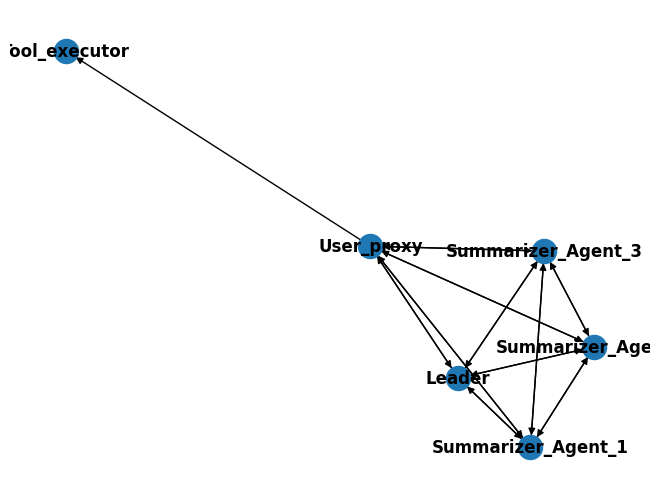

In [9]:
# Define your agents
agents = [Agent1, Agent2, Agent3, Leader, user_proxy, Agent5]

# Initialize the allowed speaker transitions dictionary
allowed_speaker_transitions_dict = {}

# Set up transitions for each agent
for agent in agents:
    if agent == Agent5:
        # Agent5 cannot send messages to any agent
        allowed_speaker_transitions_dict[agent] = []
    else:
        # Other agents can send messages to all agents except themselves and Agent5
        allowed_speaker_transitions_dict[agent] = [
            other_agent for other_agent in agents
            if other_agent != agent and other_agent != Agent5
        ]

# Allow user_proxy to send messages to Agent5
allowed_speaker_transitions_dict[user_proxy].append(Agent5)

# Visualize the transitions
visualize_speaker_transitions_dict(allowed_speaker_transitions_dict, agents)


In [10]:
def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


agents.append(user_proxy)

group_chat = GroupChat(
    agents=agents,
    messages=[],
    max_round=100,
    allowed_or_disallowed_speaker_transitions=allowed_speaker_transitions_dict,
    speaker_transitions_type="allowed",
    speaker_selection_method=custom_speaker_selection_func,
)
# Create the manager
manager = autogen.GroupChatManager(
    groupchat=group_chat,
    llm_config=llm_config,
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    code_execution_config=False,
)


In [11]:
# from autogen import register_function


# register_function(
#     read_novel,
#     caller=Agent0,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent1,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent2,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent3,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent4,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

In [12]:
# chat_result = user_proxy.initiate_chat(Agent0, message="search internet about google. Use production Manager first")

In [13]:
# Initial message

def read_moby_dick():
    """Reads the 'flatland.txt' file and returns its content as a string."""
    try:
        with open('flatland.txt', 'r', encoding='utf-8') as file:
            return file.read()
    except FileNotFoundError:
        return "Error: 'flatland.txt' not found in the current directory."
    except Exception as e:
        return f"An error occurred: {e}"
    

# Read the content of 'moby_dick.txt'
flatland_text = read_moby_dick()

# Prepare the initial message with the novel's text
initial_message = f"Delegate the work to the summarizer agents (Agent0, Agent1, Agent2) and work towards summarizing the novel Flatland'  :\n\n{flatland_text}"

# Initiate the conversation
user_proxy.initiate_chat(manager, message=initial_message)

User_proxy (to chat_manager):

Delegate the work to the summarizer agents (Agent0, Agent1, Agent2) and work towards summarizing the novel Flatland'  :

FLATLAND




PART I
THIS WORLD


“Be patient, for the world is broad and wide.”




§ 1 Of the Nature of Flatland


I call our world Flatland, not because we call it so, but to make its
nature clearer to you, my happy readers, who are privileged to live in
Space.

Imagine a vast sheet of paper on which straight Lines, Triangles,
Squares, Pentagons, Hexagons, and other figures, instead of remaining
fixed in their places, move freely about, on or in the surface, but
without the power of rising above or sinking below it, very much like
shadows—only hard with luminous edges—and you will then have a pretty
correct notion of my country and countrymen. Alas, a few years ago, I
should have said “my universe:” but now my mind has been opened to
higher views of things.

In such a country, you will perceive at once that it is impossible that
there

ChatResult(chat_id=None, chat_history=[{'content': "Delegate the work to the summarizer agents (Agent0, Agent1, Agent2) and work towards summarizing the novel Flatland'  :\n\nFLATLAND\n\n\n\n\nPART I\nTHIS WORLD\n\n\n“Be patient, for the world is broad and wide.”\n\n\n\n\n§ 1 Of the Nature of Flatland\n\n\nI call our world Flatland, not because we call it so, but to make its\nnature clearer to you, my happy readers, who are privileged to live in\nSpace.\n\nImagine a vast sheet of paper on which straight Lines, Triangles,\nSquares, Pentagons, Hexagons, and other figures, instead of remaining\nfixed in their places, move freely about, on or in the surface, but\nwithout the power of rising above or sinking below it, very much like\nshadows—only hard with luminous edges—and you will then have a pretty\ncorrect notion of my country and countrymen. Alas, a few years ago, I\nshould have said “my universe:” but now my mind has been opened to\nhigher views of things.\n\nIn such a country, you w

In [14]:
last_message = group_chat.messages[-1] if group_chat.messages else None
if last_message:
    print("Final Message Content:", last_message['content'])

Final Message Content: TERMINATE


In [15]:
def save_conversation_to_file(groupchat, filename="chat.txt"):
    """
    Save the entire conversation history to a specified file.

    Args:
        groupchat (GroupChat): The GroupChat instance containing the messages.
        filename (str): The name of the file to save the conversation history.
    """
    if not groupchat.messages:
        print("No messages in the group chat to save.")
        return

    # Compile the conversation history
    conversation_history = "\n".join(
        f"{msg['role']}: {msg['content']}" for msg in groupchat.messages
    )

    # Write the conversation history to the file
    with open(filename, "w", encoding="utf-8") as file:
        file.write(conversation_history)

    print(f"Conversation history saved to {filename}")
    
save_conversation_to_file(group_chat, filename="chat.txt")


Conversation history saved to chat.txt


In [16]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# Initialize the Llama 3.1 model
llm = ChatOpenAI(
    model="llama3.1",
    base_url="http://44.221.48.158:11434/v1"
)

def structure_logs_with_local_llm(file_path, initial_message):
    """
    Reads chat logs from a file and generates a structured summary.

    Args:
        file_path (str): Path to the chat log file.
        initial_message (str): The initial task or prompt for context.

    Returns:
        str: The structured summary generated by the LLM.
    """
    # Read the chat logs from the file
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            log_context = file.read()
    except FileNotFoundError:
        return "Error: The specified file was not found."
    except Exception as e:
        return f"An error occurred while reading the file: {e}"

    # Prepare the messages for the LLM
    messages = [
        {
            "role": "system",
            "content": (
                "You are a professional chat summarizer who goes through the entire chat and creates a proper summary based on the '{initial_message}'."
            )
        },
        {
            "role": "user",
            "content": (
                f"Convert the following agent logs into a structured format and into a proper summarized final output "
                f"based on the task '{initial_message}'.\n\nLogs:\n{log_context}"
            )
        }
    ]

    # Generate the structured summary using the LLM
    try:
        response = llm.invoke(messages)
        if isinstance(response, AIMessage):
            structured_summary = response.content
        else:
            structured_summary = "Unexpected response type from the model."
    except Exception as e:
        structured_summary = f"An error occurred during LLM processing: {e}"

    return structured_summary


In [17]:
# Define the path to your chat log file and the initial task message
file_path = 'chat.txt'
initial_message = 'Design a comprehensive digital marketing course.'

# Generate the structured summary
summary = structure_logs_with_local_llm(file_path, initial_message)

# Output the summary
print(summary)

An error occurred during LLM processing: Request timed out.


In [3]:
import graphviz

def create_sequence_diagram(output_filename='sequence_diagram', output_format='png'):
    # Initialize the Digraph
    dot = graphviz.Digraph(name="Leader-Driven-MultiAgent",
                           comment="Approximate Sequence Diagram",
                           format=output_format)

    # We set the graph to go top-to-bottom (rankdir=TB).
    dot.attr(rankdir='TB', splines='ortho', nodesep='0.6', ranksep='1.5')

    # Define each participant as a separate node, arranged vertically.
    # Using shape='rectangle' or 'none' can help with the UML style look.
    dot.node('U', 'User', shape='rectangle', style='rounded,filled',
             fillcolor='#cce5ff')
    dot.node('L', 'Leader', shape='rectangle', style='rounded,filled',
             fillcolor='#d4edda')
    dot.node('M', 'Memory (M)', shape='rectangle', style='rounded,filled',
             fillcolor='#fff3cd')
    dot.node('S', 'Speaker Selector Agent (SSA)', shape='rectangle',
             style='rounded,filled', fillcolor='#f8d7da')
    dot.node('A', 'Content Agent', shape='rectangle', style='rounded,filled',
             fillcolor='#e2e3e5')
    dot.node('P', 'User Proxy', shape='rectangle', style='rounded,filled',
             fillcolor='#cfe2ff')

    # We'll represent each message as an edge from one node to the next,
    # placed in vertical order by adding constraints in a rough top-down sequence.

    # 1) User --> Leader: Provide Task
    dot.edge('U', 'L', label='1) Provide Task Prompt')

    # 2) Leader --> Memory: Insert Task
    # We add a constraint (minlen) to place it somewhat below the first arrow.
    dot.edge('L', 'M', label='2) Initialize Problem', minlen='2')

    # 3) Content Agent reads from Memory: Partial solutions
    dot.edge('M', 'A', label='3) Agent Reads Task', minlen='2')

    # 4) Content Agent --> Memory: Posts partial solution
    dot.edge('A', 'M', label='4) Append Partial Solution')

    # 5) Memory --> SSA: SSA invoked after each message
    dot.edge('M', 'S', label='5) SSA Invoked')

    # 6) SSA --> Next Agent (could be the same or different)
    # For demonstration, we show it selecting the same 'Content Agent' 
    dot.edge('S', 'A', label='6) SSA Finalizes Next Speaker')

    # 7) Eventually Leader sees solution is complete and signals termination
    dot.edge('L', 'M', label='7) Leader Posts Final Answer + Termination',
             minlen='2')

    # 8) Memory notifies User Proxy: Termination Detected
    dot.edge('M', 'P', label='8) Detected Termination Signal')

    # 9) User Proxy --> User: Return Final Result
    dot.edge('P', 'U', label='9) Return Solution to User', minlen='2')

    # Finally, render the diagram to file
    dot.render(filename=output_filename, cleanup=True)
    print(f"Sequence diagram generated: {output_filename}.{output_format}")


if __name__ == '__main__':
    create_sequence_diagram(output_filename='sequence_diagram', output_format='png')


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [2]:
pip install graphviz


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
